In [1]:
#!pip install TCT

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import TCT
from TCT import TCT_pathfinder
from TCT import pathfinder
from TCT import TCT_neighborhood_finder

import matplotlib.pyplot as plt
import requests

In [2]:
APInames, metaKG, Translator_KP_info= translator_metakg.load_translator_resources(use_new_metakg_url=True)

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}


In [3]:
url = 'https://amlkg.systemsbiology.org:9990/AMLkg/meta_knowledge_graph'
response = requests.get(url, verify=False)
data = response.json()

for i in range(len(data["edges"])):
    APInames, metaKG = translator_metakg.add_new_API_for_query(APInames, metaKG, "AMLKG", "https://amlkg.systemsbiology.org:9990/AMLkg/query/", data["edges"][i]['predicate'], data["edges"][i]['subject'], data["edges"][i]['object'])

API_withMetaKG = list(set(metaKG['API']))
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))


SSLError: HTTPSConnectionPool(host='amlkg.systemsbiology.org', port=9990): Max retries exceeded with url: /AMLkg/meta_knowledge_graph (Caused by SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1032)')))

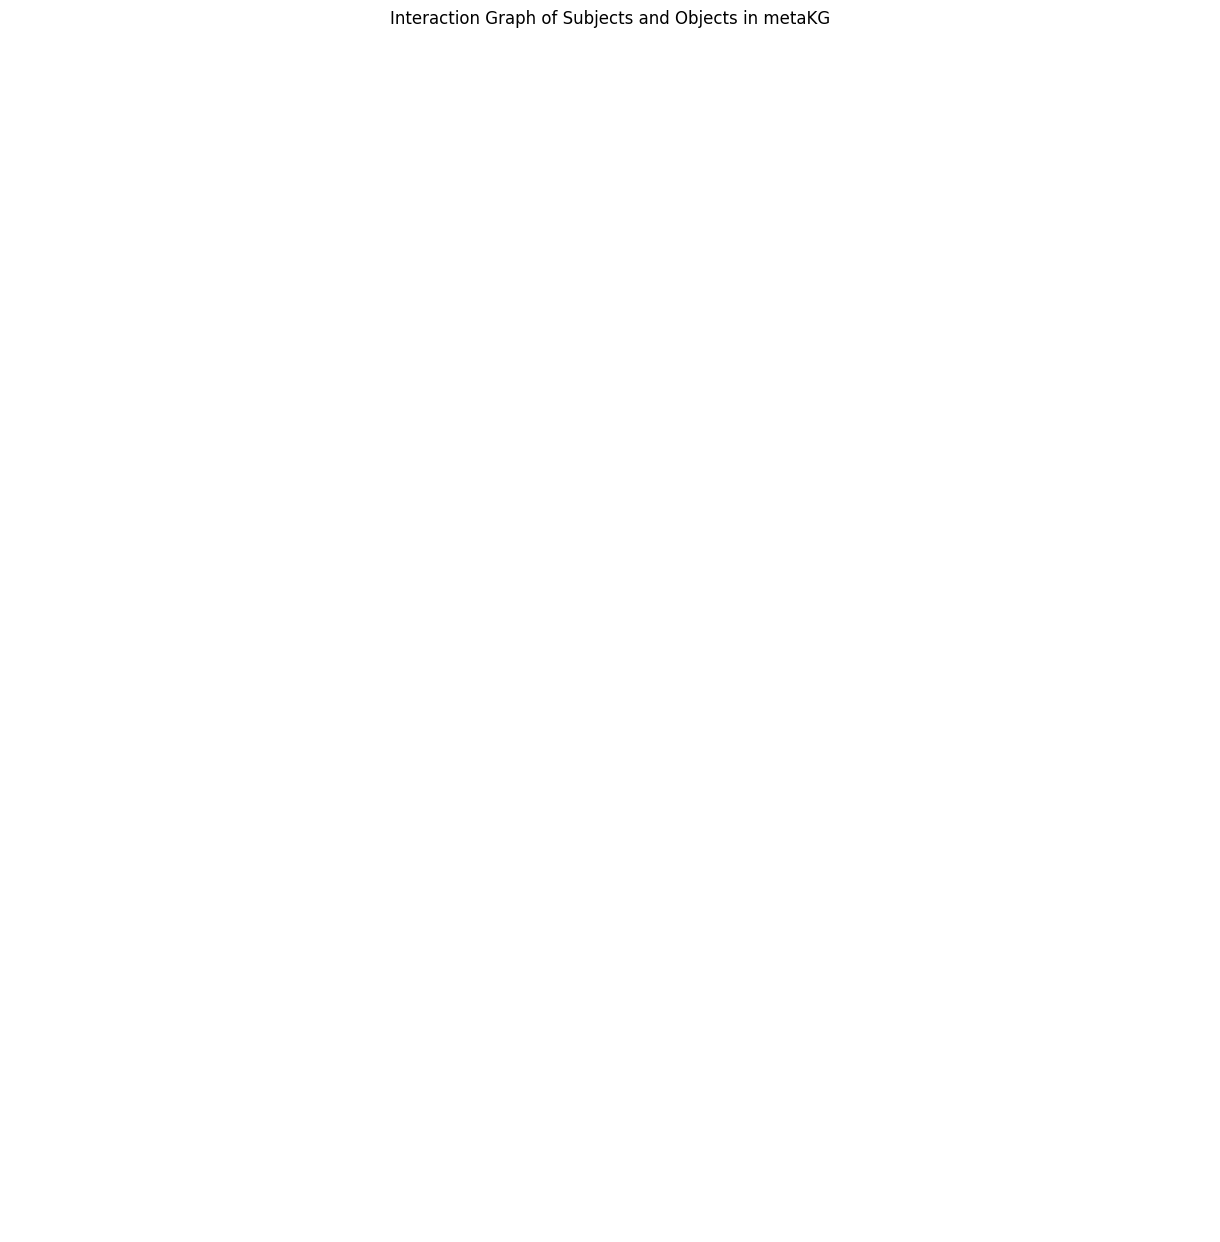

In [4]:
import networkx as nx
selected_KGs = ['AMLKG']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

# build a multigraph to capture all edges (including duplicates) and their predicates
G = nx.MultiGraph()
for _, row in metaKG_sele.iterrows():
        G.add_edge(row['Subject'], row['Object'], predicate=row['Predicate'])

# layout and draw nodes + edges
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos,
                with_labels=True,
                node_size=50,
                font_size=12,
                font_color='black',
                node_color='blue',
                edge_color='gray')

# draw edge labels
edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Interaction Graph of Subjects and Objects in metaKG')
plt.show()

In [5]:
# select a list of APIs to use and a list of predicates to use


selected_APIlist = ['AMLKG',
                    'Retriever',
                    'Clinical Trials KP - TRAPI 1.5.0',
                    'Drug Approvals KP - TRAPI 1.5.0',
                    'Genetics Data Provider for NCATS Biomedical Translator Reasoners',
                    #'Microbiome KP - TRAPI 1.5.0',
                    #'MolePro',
                    #'COHD TRAPI',
                    'RTX KG2 - TRAPI 1.5.0',
                    #'Text Mined Cooccurrence API',
                    'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0',
                    'CATRAX Pharmacogenomics KP - TRAPI 1.5.0',
                    ]

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
print(select_APIs)
print(selected_metaKG.shape)

{'Retriever': 'https://retriever.ci.transltr.io/query/', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Genetics Data Provider for NCATS Biomedical Translator Reasoners': 'https://genetics-kp.transltr.io/genetics_provider/trapi/v1.5/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query'}
(14998, 5)


In [6]:
metaKG.loc[metaKG['API'] == 'AMLKG',['API','Predicate','Subject','Object']].drop_duplicates()

,API,Predicate,Subject,Object


In [7]:
#name_resolver.lookup('miR-155', only_taxa='NCBITaxon:9606')
subject_name = 'BCL2'
subject_node = name_resolver.lookup(subject_name, only_taxa='NCBITaxon:9606').curie

subject_category = name_resolver.lookup(subject_name).types
subject_category = ["biolink:Gene", "biolink:Protein"]

object_name = 'acute myeloid leukemia'
object_node = name_resolver.lookup(object_name, biolink_category='biolink:Disease').curie
object_category = name_resolver.lookup(object_name, biolink_category='biolink:Disease').types
object_category = ["biolink:Disease"]

intermediate_categories = [ 'biolink:Drug','biolink:SmallMolecule','biolink:ChemicalSubstance','biolink:Gene','biolink:Protein']

In [8]:
subject_name = 'venetoclax'
subject_node = name_resolver.lookup(subject_name).curie
subject_node

'CHEBI:133021'

In [9]:
print(f"Subject: {subject_name}, CURIE: {subject_node}, Category: {subject_category}")
print(f"Object: {object_name}, CURIE: {object_node}, Category: {object_category}")

Subject: venetoclax, CURIE: CHEBI:133021, Category: ['biolink:Gene', 'biolink:Protein']
Object: acute myeloid leukemia, CURIE: MONDO:0018874, Category: ['biolink:Disease']


In [10]:
# test neighborhood finder by adding a new API to the metaKG
finder_result = TCT_neighborhood_finder.neighborhood_finder(
    subject_node,
    # neighbor_categories=['biolink:Drug', 'biolink:SmallMolecule', 'biolink:ChemicalSubstance'],
    # neighbor_categories=['biolink:AnatomicalEntity'],
    neighbor_categories=['biolink:Disease'],
    api_names=select_APIs,
    meta_kg=selected_metaKG,
    api_predicates=API_predicates,
    node_categories=['biolink:Gene'],
)
TCT_neighborhood_finder_result = finder_result.raw


Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
59


(18613, 5)


(30172, 5)


RTX KG2 - TRAPI 1.5.0: Success!
Retriever: Success!


In [11]:
input_identifiers = subject_node
import datetime
import json
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
with open('TCT_neighborhood_finder_result_'+input_identifiers.replace(':', '_')+'_'+timestamp+'.json', 'w') as f:
    json.dump(TCT_neighborhood_finder_result, f)

In [12]:
# test pathfinder by adding a new API to the metaKG
result = pathfinder(start=subject_node,  # e.g. IFNG
                    end=object_node,  # e.g. disease node
                    intermediate_categories=intermediate_categories,
                    api_names=select_APIs,
                    meta_kg=selected_metaKG,
                    api_predicates=API_predicates)


CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!


RTX KG2 - TRAPI 1.5.0: Success!


CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Drug Approvals KP - TRAPI 1.5.0: Success!


CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0: Success!


RTX KG2 - TRAPI 1.5.0: Success!


Clinical Trials KP - TRAPI 1.5.0: Success!


In [13]:
# pathfinder already returns parsed results inside a FinderResult
import json
with open(f'TCT_path_finder_result__{subject_node.replace(":", "_")}__{object_node.replace(":", "_")}.json', 'w') as f:
    json.dump(result.to_dict(), f, indent=4)
